# 03 特征工程

基于清洗后数据，按以下维度扩充特征：

| 模块 | 内容 |
|------|------|
| 1 | 加载数据 & 现有特征概览 |
| 2 | 对数变换（偏态特征） |
| 3 | 年龄分箱 |
| 4 | 信用使用率分箱 |
| 5 | 比率 / 交叉特征 |
| 6 | 逾期严重度加权分 |
| 7 | 特征与目标相关性分析 |
| 8 | 互信息特征重要性 |
| 9 | 特征集总结 & 保存 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/train_clean.csv')

print('shape:', df.shape)
print('\n现有列:')
for c in df.columns:
    print(' ', c)

shape: (149391, 21)

现有列:
  SeriousDlqin2yrs
  RevolvingUtilizationOfUnsecuredLines
  age
  NumberOfTime30-59DaysPastDueNotWorse
  DebtRatio
  MonthlyIncome
  NumberOfOpenCreditLinesAndLoans
  NumberOfTimes90DaysLate
  NumberRealEstateLoansOrLines
  NumberOfTime60-89DaysPastDueNotWorse
  NumberOfDependents
  MonthlyIncome_missing
  NumberOfDependents_missing
  age_missing
  NumberOfTime30-59DaysPastDueNotWorse_missing
  NumberOfTime60-89DaysPastDueNotWorse_missing
  NumberOfTimes90DaysLate_missing
  ever_late_30
  ever_late_60
  ever_late_90
  total_late


## 模块 2：对数变换

`MonthlyIncome` 和 `DebtRatio` 偏度分别约为 5.4 和 4.5，对数变换可压缩长尾、改善线性模型的拟合。
`RevolvingUtilizationOfUnsecuredLines` 已截断至 [0,1]，用 log1p 变换后可拉伸低值区间的分辨率。

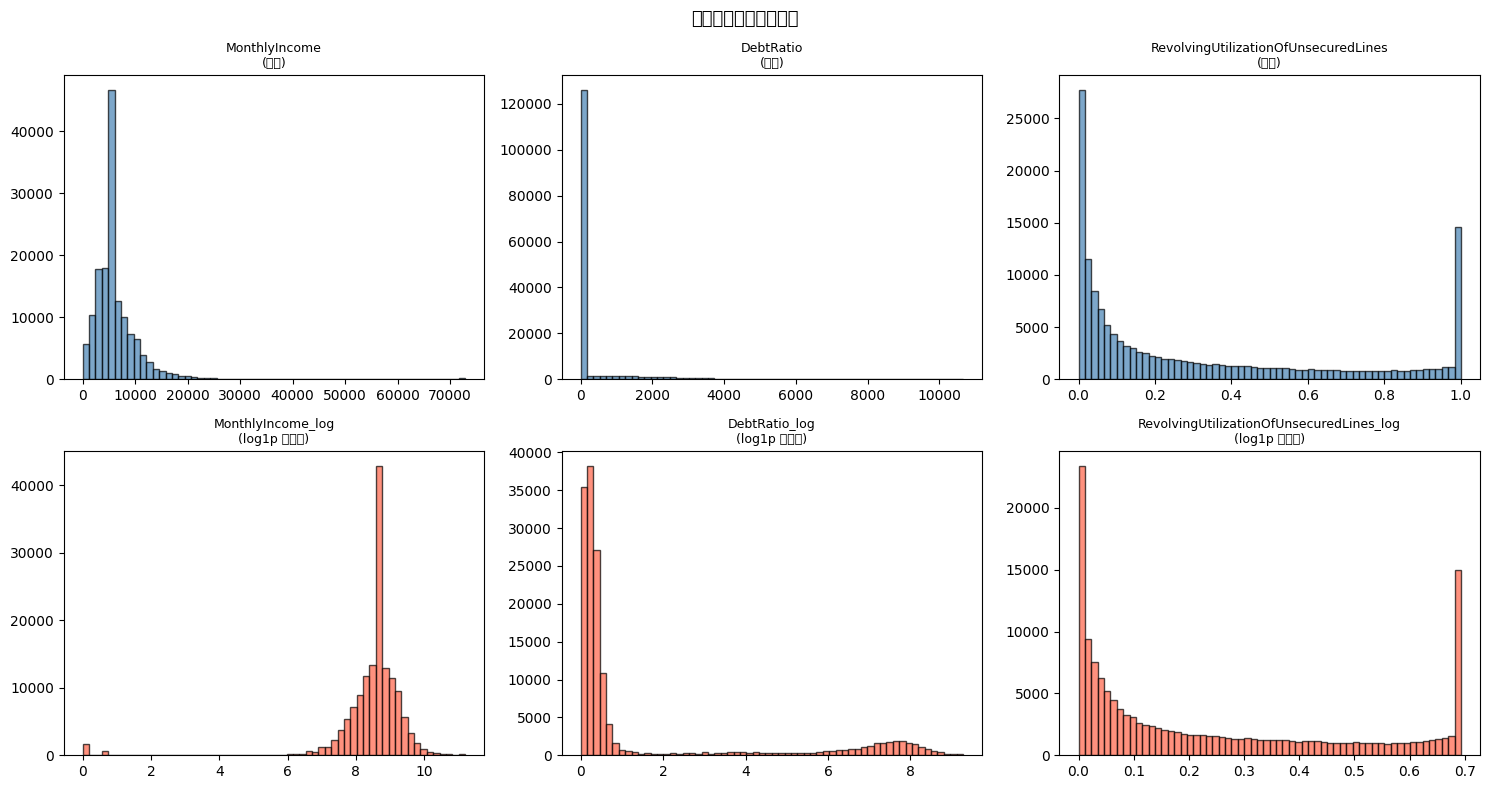

变换后偏度:
  MonthlyIncome                                  before=  5.37  after= -4.97
  DebtRatio                                      before=  4.46  after=  1.74
  RevolvingUtilizationOfUnsecuredLines           before=  0.89  after=  0.71


In [2]:
log_cols = ['MonthlyIncome', 'DebtRatio', 'RevolvingUtilizationOfUnsecuredLines']

for col in log_cols:
    df[f'{col}_log'] = np.log1p(df[col])

# 可视化变换效果
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(log_cols):
    axes[0, i].hist(df[col], bins=60, color='steelblue', alpha=0.7, edgecolor='k')
    axes[0, i].set_title(f'{col}\n(原始)', fontsize=9)

    axes[1, i].hist(df[f'{col}_log'], bins=60, color='tomato', alpha=0.7, edgecolor='k')
    axes[1, i].set_title(f'{col}_log\n(log1p 变换后)', fontsize=9)

plt.suptitle('对数变换前后分布对比', fontsize=13)
plt.tight_layout()
plt.show()

print('变换后偏度:')
for col in log_cols:
    s_before = df[col].skew()
    s_after  = df[f'{col}_log'].skew()
    print(f'  {col:45s}  before={s_before:6.2f}  after={s_after:6.2f}')

## 模块 3：年龄分箱

年龄是信用风险的重要因子，不同年龄段的信贷行为有明显差异。将连续年龄离散化为 5 个年龄段。

                  违约率    样本量
age_group                   
young(<30)     0.1192   8609
adult(30-45)   0.0950  38920
middle(45-60)  0.0704  53789
senior(60-75)  0.0345  36816
elder(75+)     0.0203  11257


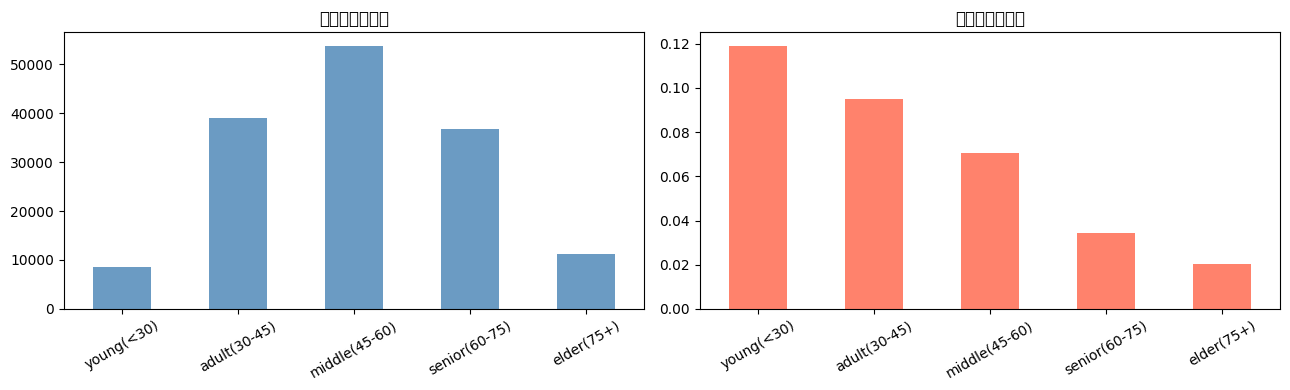

In [3]:
age_bins   = [0, 30, 45, 60, 75, 120]
age_labels = ['young(<30)', 'adult(30-45)', 'middle(45-60)', 'senior(60-75)', 'elder(75+)']

df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)
df['age_group_code'] = df['age_group'].cat.codes   # 供树模型直接使用

# 各年龄段违约率
age_default = df.groupby('age_group', observed=True)['SeriousDlqin2yrs'].agg(['mean', 'count'])
age_default.columns = ['违约率', '样本量']
print(age_default.round(4))

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
age_default['样本量'].plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('各年龄段样本量')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

age_default['违约率'].plot(kind='bar', ax=axes[1], color='tomato', alpha=0.8)
axes[1].set_title('各年龄段违约率')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 模块 4：信用使用率分箱

`RevolvingUtilizationOfUnsecuredLines` 已截断至 [0,1]，按风险梯度分箱：低使用（安全）→ 高度使用（高风险）。

                      违约率    样本量
util_group                      
low(0-30%)         0.0223  92573
medium(30-60%)     0.0668  21887
high(60-80%)       0.1193  10098
very_high(80-90%)  0.1602   5063
maxed(90-100%)     0.2261  19770


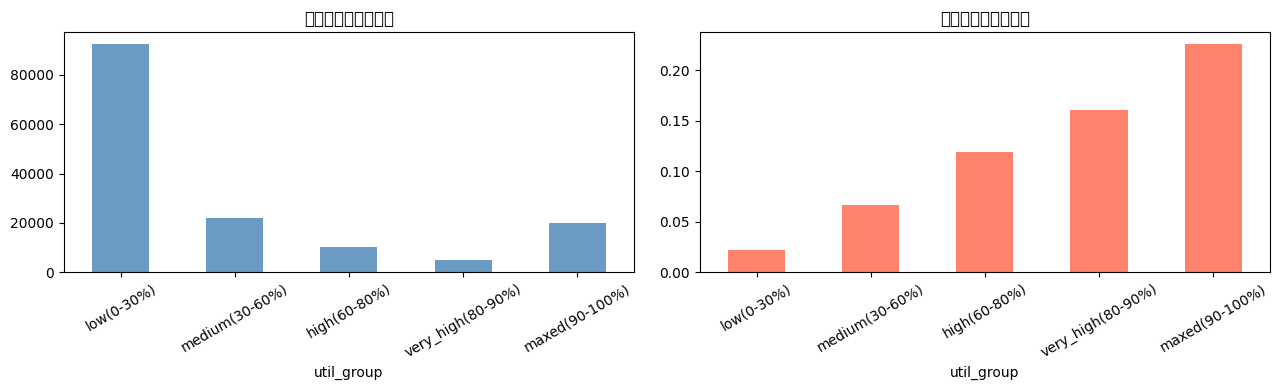

In [4]:
util_bins   = [0, 0.3, 0.6, 0.8, 0.9, 1.0001]
util_labels = ['low(0-30%)', 'medium(30-60%)', 'high(60-80%)', 'very_high(80-90%)', 'maxed(90-100%)']

df['util_group'] = pd.cut(
    df['RevolvingUtilizationOfUnsecuredLines'],
    bins=util_bins, labels=util_labels, right=False
)
df['util_group_code'] = df['util_group'].cat.codes

util_default = df.groupby('util_group', observed=True)['SeriousDlqin2yrs'].agg(['mean', 'count'])
util_default.columns = ['违约率', '样本量']
print(util_default.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
util_default['样本量'].plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('各使用率档位样本量')
axes[0].tick_params(axis='x', rotation=30)

util_default['违约率'].plot(kind='bar', ax=axes[1], color='tomato', alpha=0.8)
axes[1].set_title('各使用率档位违约率')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 模块 5：比率 / 交叉特征

构造更具业务含义的衍生特征，捕捉原始变量之间的非线性关系。

In [5]:
# --- 负债 / 收入 ---
# 估算月度绝对债务金额（DebtRatio * MonthlyIncome）
df['monthly_debt_est'] = df['DebtRatio'] * df['MonthlyIncome']
df['monthly_debt_est_log'] = np.log1p(df['monthly_debt_est'])

# 每条信用线平均负债率（负债分散程度）
df['debt_per_credit_line'] = df['DebtRatio'] / (df['NumberOfOpenCreditLinesAndLoans'] + 1)

# 每位被抚养人的月收入（收入压力）
df['income_per_dependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)
df['income_per_dependent_log'] = np.log1p(df['income_per_dependent'])

# --- 信贷行为 / 年龄 ---
# 每年新增的信用线数量（信贷扩张速度代理）
df['credit_line_per_age'] = df['NumberOfOpenCreditLinesAndLoans'] / (df['age'] + 1)

# 房产贷款占全部信用线比例（资产质量）
df['real_estate_ratio'] = (
    df['NumberRealEstateLoansOrLines']
    / (df['NumberOfOpenCreditLinesAndLoans'] + 1)
)

# --- 信用使用率 × 逾期历史（高使用率 + 有逾期 = 双重风险） ---
df['util_x_late'] = df['RevolvingUtilizationOfUnsecuredLines'] * df['total_late']

print('新增比率/交叉特征:')
ratio_features = [
    'monthly_debt_est', 'monthly_debt_est_log',
    'debt_per_credit_line', 'income_per_dependent', 'income_per_dependent_log',
    'credit_line_per_age', 'real_estate_ratio', 'util_x_late',
]
print(df[ratio_features].describe().T[['mean', 'std', 'min', 'max']].round(3))

新增比率/交叉特征:
                                 mean          std  min           max
monthly_debt_est          1712194.564  5438677.011  0.0  5.755396e+07
monthly_debt_est_log            8.301        3.819  0.0  1.786800e+01
debt_per_credit_line           39.595      119.951  0.0  4.480000e+03
income_per_dependent         4514.662     3880.279  0.0  7.285477e+04
income_per_dependent_log        8.057        1.220  0.0  1.119600e+01
credit_line_per_age             0.166        0.103  0.0  1.326000e+00
real_estate_ratio               0.106        0.111  0.0  9.150000e-01
util_x_late                     0.249        0.892  0.0  1.900000e+01


## 模块 6：逾期严重度加权分

三个逾期字段分别对应 30-59 天、60-89 天、90+ 天，越长越严重。
用加权分数综合衡量历史逾期的严重程度：`w30×1 + w60×2 + w90×4`。

late_severity 分布（违约 vs 正常）:
                     count   mean    std  min  25%  50%  75%   max
SeriousDlqin2yrs                                                  
0                 139382.0  0.478  1.754  0.0  0.0  0.0  0.0  61.0
1                  10009.0  4.365  6.135  0.0  0.0  2.0  6.0  68.0


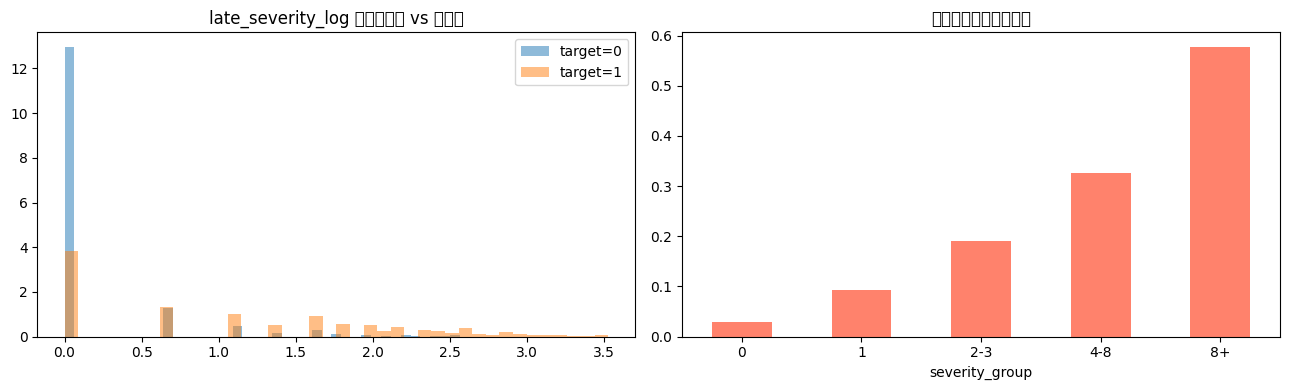

In [6]:
df['late_severity'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] * 1
    + df['NumberOfTime60-89DaysPastDueNotWorse'] * 2
    + df['NumberOfTimes90DaysLate'] * 4
)
df['late_severity_log'] = np.log1p(df['late_severity'])

# 验证：加权分 vs 违约率
print('late_severity 分布（违约 vs 正常）:')
print(df.groupby('SeriousDlqin2yrs')['late_severity'].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label, grp in df.groupby('SeriousDlqin2yrs'):
    data = grp['late_severity_log'].clip(upper=grp['late_severity_log'].quantile(0.995))
    axes[0].hist(data, bins=40, alpha=0.5, label=f'target={label}', density=True)
axes[0].set_title('late_severity_log 分布（违约 vs 正常）')
axes[0].legend()

severity_bins = [-0.1, 0, 1, 3, 8, 100]
df['severity_group'] = pd.cut(df['late_severity'], bins=severity_bins,
                               labels=['0', '1', '2-3', '4-8', '8+'])
sev_rate = df.groupby('severity_group', observed=True)['SeriousDlqin2yrs'].mean()
sev_rate.plot(kind='bar', ax=axes[1], color='tomato', alpha=0.8)
axes[1].set_title('各逾期严重度组违约率')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 模块 7：特征与目标相关性分析

与目标变量的绝对相关系数 (Top 20):
late_severity_log                               0.4054
util_x_late                                     0.3923
total_late                                      0.3889
late_severity                                   0.3860
ever_late_90                                    0.3300
NumberOfTimes90DaysLate                         0.3119
util_group_code                                 0.2845
RevolvingUtilizationOfUnsecuredLines            0.2793
RevolvingUtilizationOfUnsecuredLines_log        0.2725
NumberOfTime30-59DaysPastDueNotWorse            0.2715
NumberOfTime60-89DaysPastDueNotWorse            0.2657
ever_late_60                                    0.2641
ever_late_30                                    0.2381
age                                             0.1157
age_group_code                                  0.1112
NumberOfTimes90DaysLate_missing                 0.0835
NumberOfTime60-89DaysPastDueNotWorse_missing    0.0835
NumberOfTime30-59DaysPastDueNotWorse_missi

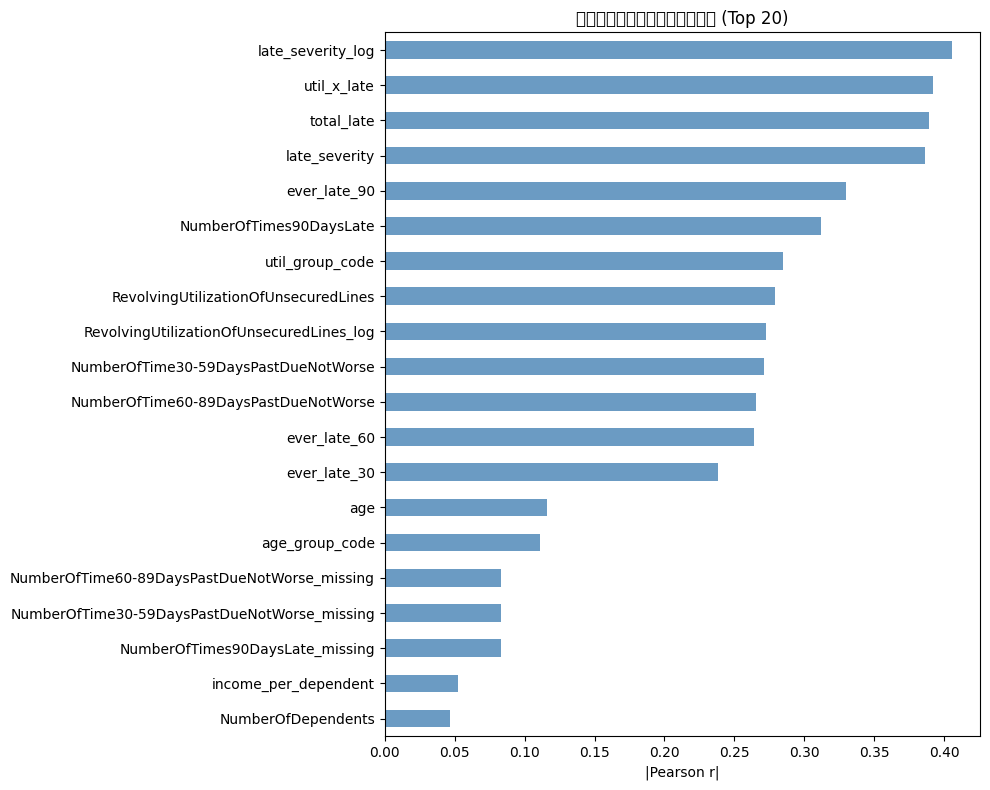

In [7]:
# 排除分类列和目标列
exclude = ['SeriousDlqin2yrs', 'age_group', 'util_group', 'severity_group']
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]

corr_with_target = (
    df[num_cols + ['SeriousDlqin2yrs']]
    .corr()['SeriousDlqin2yrs']
    .drop('SeriousDlqin2yrs')
    .abs()
    .sort_values(ascending=False)
)

print('与目标变量的绝对相关系数 (Top 20):')
print(corr_with_target.head(20).round(4))

plt.figure(figsize=(10, 8))
corr_with_target.head(20).sort_values().plot(kind='barh', color='steelblue', alpha=0.8)
plt.title('特征与目标变量的绝对相关系数 (Top 20)')
plt.xlabel('|Pearson r|')
plt.tight_layout()
plt.show()

## 模块 8：互信息特征重要性

Pearson 相关系数只捕捉线性关系，互信息（Mutual Information）能捕捉非线性依赖，更适合评估分类特征对目标的贡献。

互信息得分 (Top 20):
late_severity                               0.05039
late_severity_log                           0.05006
util_x_late                                 0.04983
total_late                                  0.04719
RevolvingUtilizationOfUnsecuredLines        0.03673
RevolvingUtilizationOfUnsecuredLines_log    0.03589
util_group_code                             0.03588
NumberOfTimes90DaysLate                     0.02932
ever_late_90                                0.02788
NumberOfTime30-59DaysPastDueNotWorse        0.02564
ever_late_30                                0.02246
NumberOfTime60-89DaysPastDueNotWorse        0.02051
ever_late_60                                0.01949
age_group_code                              0.01313
age                                         0.00887
credit_line_per_age                         0.00754
NumberRealEstateLoansOrLines                0.00630
NumberOfOpenCreditLinesAndLoans             0.00585
debt_per_credit_line                        0.00

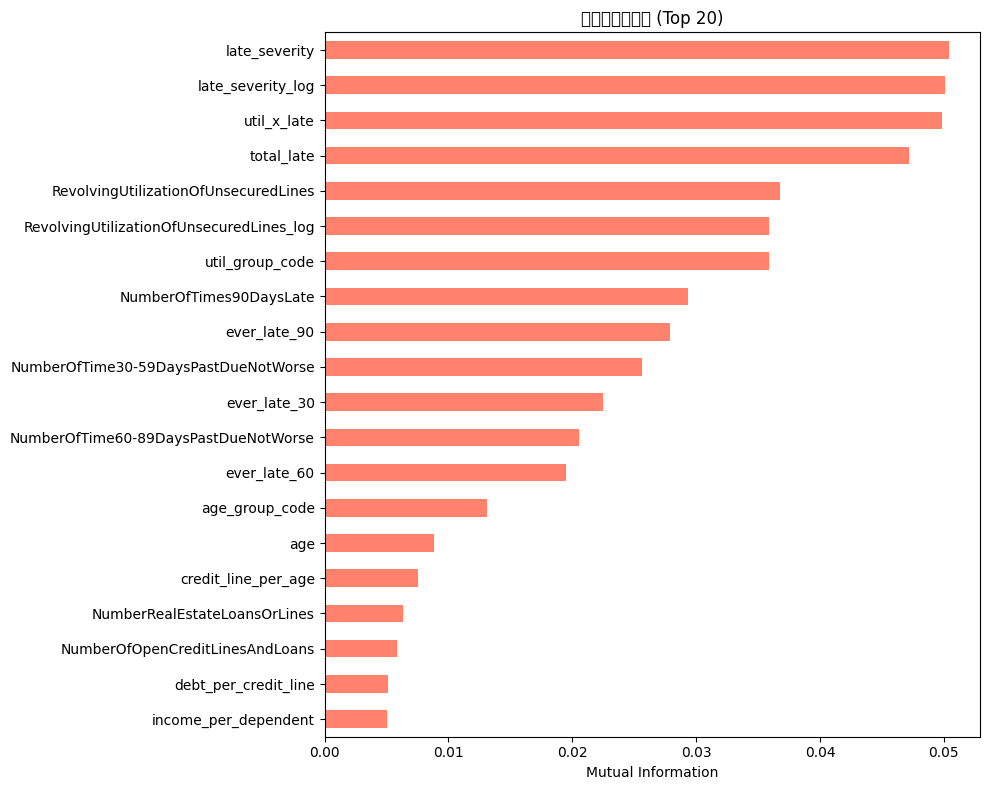

In [8]:
X = df[num_cols].fillna(0)
y = df['SeriousDlqin2yrs']

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=num_cols).sort_values(ascending=False)

print('互信息得分 (Top 20):')
print(mi_series.head(20).round(5))

plt.figure(figsize=(10, 8))
mi_series.head(20).sort_values().plot(kind='barh', color='tomato', alpha=0.8)
plt.title('特征互信息得分 (Top 20)')
plt.xlabel('Mutual Information')
plt.tight_layout()
plt.show()

## 模块 9：特征集总结 & 保存

In [9]:
# 定义最终建模特征集（排除中间辅助列）
drop_cols = ['age_group', 'util_group', 'severity_group']   # Categorical，已有 code 版
df_model = df.drop(columns=drop_cols)

# 特征分组清单
feature_groups = {
    'original': [
        'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome',
        'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines',
        'NumberOfDependents',
        'NumberOfTime30-59DaysPastDueNotWorse',
        'NumberOfTime60-89DaysPastDueNotWorse',
        'NumberOfTimes90DaysLate',
    ],
    'missing_flags': [c for c in df_model.columns if c.endswith('_missing')],
    'delinquency': ['ever_late_30', 'ever_late_60', 'ever_late_90', 'total_late',
                    'late_severity', 'late_severity_log'],
    'log_transform': [c for c in df_model.columns if c.endswith('_log')],
    'binning': ['age_group_code', 'util_group_code'],
    'ratio_interact': [
        'monthly_debt_est', 'debt_per_credit_line',
        'income_per_dependent', 'credit_line_per_age',
        'real_estate_ratio', 'util_x_late',
    ],
}

print('=== 最终特征集 ===')
total = 0
for group, cols in feature_groups.items():
    print(f'\n[{group}] ({len(cols)} 个)')
    for c in cols:
        print(f'  {c}')
    total += len(cols)
print(f'\n合计: {total} 个特征 + 1 个目标变量')
print(f'df_model shape: {df_model.shape}')

=== 最终特征集 ===

[original] (10 个)
  RevolvingUtilizationOfUnsecuredLines
  age
  DebtRatio
  MonthlyIncome
  NumberOfOpenCreditLinesAndLoans
  NumberRealEstateLoansOrLines
  NumberOfDependents
  NumberOfTime30-59DaysPastDueNotWorse
  NumberOfTime60-89DaysPastDueNotWorse
  NumberOfTimes90DaysLate

[missing_flags] (6 个)
  MonthlyIncome_missing
  NumberOfDependents_missing
  age_missing
  NumberOfTime30-59DaysPastDueNotWorse_missing
  NumberOfTime60-89DaysPastDueNotWorse_missing
  NumberOfTimes90DaysLate_missing

[delinquency] (6 个)
  ever_late_30
  ever_late_60
  ever_late_90
  total_late
  late_severity
  late_severity_log

[log_transform] (6 个)
  MonthlyIncome_log
  DebtRatio_log
  RevolvingUtilizationOfUnsecuredLines_log
  monthly_debt_est_log
  income_per_dependent_log
  late_severity_log

[binning] (2 个)
  age_group_code
  util_group_code

[ratio_interact] (6 个)
  monthly_debt_est
  debt_per_credit_line
  income_per_dependent
  credit_line_per_age
  real_estate_ratio
  util_x_late

合

In [10]:
import os
os.makedirs('../data/processed', exist_ok=True)

df_model.to_csv('../data/processed/train_features.csv', index=False)
print('已保存: ../data/processed/train_features.csv')
print('shape:', df_model.shape)

已保存: ../data/processed/train_features.csv
shape: (149391, 36)


## 特征工程总结

### 新增特征一览

| 模块 | 特征名 | 说明 |
|------|--------|------|
| 对数变换 | `MonthlyIncome_log` | log1p(月收入)，压缩右偏 |
| 对数变换 | `DebtRatio_log` | log1p(负债率)，压缩右偏 |
| 对数变换 | `RevolvingUtilizationOfUnsecuredLines_log` | log1p(信用使用率) |
| 年龄分箱 | `age_group_code` | 5 档：<30 / 30-45 / 45-60 / 60-75 / 75+ |
| 使用率分箱 | `util_group_code` | 5 档：0-30% / 30-60% / 60-80% / 80-90% / 90-100% |
| 比率特征 | `monthly_debt_est` | DebtRatio × MonthlyIncome（估算月债务） |
| 比率特征 | `monthly_debt_est_log` | log1p(月债务估算) |
| 比率特征 | `debt_per_credit_line` | DebtRatio / (信用线数+1) |
| 比率特征 | `income_per_dependent` | MonthlyIncome / (被抚养人数+1) |
| 比率特征 | `income_per_dependent_log` | log1p(人均收入) |
| 比率特征 | `credit_line_per_age` | 信用线数 / (年龄+1) |
| 比率特征 | `real_estate_ratio` | 房产贷款 / (总信用线+1) |
| 交叉特征 | `util_x_late` | 信用使用率 × 逾期次数合计 |
| 逾期加权 | `late_severity` | 30d×1 + 60d×2 + 90d×4 |
| 逾期加权 | `late_severity_log` | log1p(逾期严重度) |

---

### 输出文件

| 文件 | 说明 |
|------|------|
| `data/processed/train_features.csv` | 完整特征工程后的训练集，供建模使用 |

---

### 建模注意事项

- **树模型（XGBoost / LightGBM / RandomForest）**：可直接使用全部特征，对数变换可选
- **线性模型（LR / SVM）**：推荐使用 `_log` 变换版本，并做标准化（StandardScaler）
- **特征冗余**：`ever_late_*` 与原始逾期计数高度相关，线性模型中可二选一
- **类别不平衡**：建模时仍需 `class_weight='balanced'` 或 SMOTE